In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# Unsupervised Clustering Project

This notebook provides a boilerplate structure for an unsupervised clustering project. It includes sections for data input, model training, and visualization of the results.

In [2]:
from typing import List, Optional, Sequence, Dict, Iterable
from __future__ import annotations
from dataclasses import dataclass

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans # Example clustering algorithm
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

import polars as pl
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from matplotlib import dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import math





from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


## 1. Data Input

Specify the path to your parquet data file and load it into a pandas DataFrame.

In [3]:
def lazy_sample_parquet(
    path: str,
    fraction: float = 0.05,
    seed: int = 42,
    columns: list[str] | None = None,
    stratify_col: str | None = None,
) -> pl.DataFrame:
    """
    Low-memory sampling loader that works even if LazyFrame.sample() isn't available.
    - Loads a small random subset of rows directly from disk.
    - fraction = fraction of total rows to load (0–1)
    - columns = list of columns to read (for column pruning)
    - stratify_col = optional column to preserve distribution (lightweight, approximate)
    """
    # Step 1: Read just the schema to see what’s available
    schema = pl.read_parquet(path, n_rows=0).schema
    available_cols = list(schema.keys())
    if columns:
        columns = [c for c in columns if c in available_cols]
    else:
        columns = available_cols

    # Step 2: If stratification requested, read that column separately (small)
    if stratify_col and stratify_col in available_cols:
        small_col = pl.read_parquet(path, columns=[stratify_col])
        unique_vals = small_col[stratify_col].unique()
        n_groups = len(unique_vals)
        print(f"Stratifying by '{stratify_col}' across {n_groups:,} groups.")

        # Take a small fraction from each group (roughly)
        sampled_groups = []
        for val in unique_vals:
            mask = small_col[stratify_col] == val
            idx = np.where(mask)[0]
            n_take = max(1, int(len(idx) * fraction))
            chosen_idx = np.random.default_rng(seed).choice(idx, size=n_take, replace=False)
            sampled_groups.append(chosen_idx)
        take_indices = np.concatenate(sampled_groups)
        # This is only feasible if your file isn't > few hundred MBs
        return pl.read_parquet(path, columns=columns, row_indices=take_indices.tolist())

    # Step 3: No stratification → use chunked row-group sampling
    # Count total row groups without loading all data
    meta = pl.read_parquet(path, n_rows=0)
    # Determine rough number of rows per group (approx)
    total_rows = None
    try:
        # Some Polars versions expose this
        total_rows = meta.shape[0]
    except Exception:
        pass

    # Simple fallback: random row group fraction
    print(f"Sampling ≈{fraction*100:.1f}% of rows (columns={len(columns)})")
    df = pl.read_parquet(path, columns=columns)
    n = df.height
    take_n = int(max(1, n * fraction))
    idx = np.random.default_rng(seed).choice(n, take_n, replace=False)
    sample_df = df[idx]
    print(f"Loaded {sample_df.height:,} rows out of {n:,}")
    return sample_df


In [4]:
# Usage - replace the original code

# PARQUET_PATH = "/content/drive/MyDrive/Copy of spy_historical_2005_2023.parquet"
PARQUET_PATH = "spy_historical_2005_2023.parquet"

numeric_features = [
    'impl_volatility', 'delta', 'theta', 'vega',
    'moneyness', 'volume', 'open_interest',
    'vol', 'volume_ma5', 'prc',
    'price_diff_1d',
    'price_diff_2d',
    'price_diff_3d',
    'price_diff_5d',
    'price_diff_8d',
    'price_diff_34d'
]

# Example: load a 5% random sample
sample_df = lazy_sample_parquet(PARQUET_PATH, fraction=0.001, columns=numeric_features)
print(sample_df.shape, sample_df.columns)


Sampling ≈0.1% of rows (columns=16)
Loaded 52,176 rows out of 52,176,345
(52176, 16) ['impl_volatility', 'delta', 'theta', 'vega', 'moneyness', 'volume', 'open_interest', 'vol', 'volume_ma5', 'prc', 'price_diff_1d', 'price_diff_2d', 'price_diff_3d', 'price_diff_5d', 'price_diff_8d', 'price_diff_34d']


## 2. Data Preprocessing and Training

Perform necessary data preprocessing steps (e.g., scaling, feature selection) and then train your chosen unsupervised clustering model.

## Split the data for supervised / unsupervised training

In [5]:
def split_for_supervised_unsupervised(
    df: pl.DataFrame,
    test_size: float = 0.5,
    random_state: int = 42
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Randomly split a Polars DataFrame into two disjoint parts:
    one for supervised and one for unsupervised learning.
    """
    # Convert just indices for speed & reproducibility
    indices = np.arange(df.height)
    idx_train, idx_unsup = train_test_split(
        indices, test_size=test_size, random_state=random_state, shuffle=True
    )

    df_supervised = df[idx_train]
    df_unsupervised = df[idx_unsup]

    print(f"Split complete:")
    print(f"  Supervised subset:   {df_supervised.height:,} rows")
    print(f"  Unsupervised subset: {df_unsupervised.height:,} rows")

    return df_supervised, df_unsupervised


In [6]:
supervised_df, unsupervised_df = split_for_supervised_unsupervised(sample_df, test_size=0.5, random_state=42)

Split complete:
  Supervised subset:   26,088 rows
  Unsupervised subset: 26,088 rows


### PCA

In [7]:
def apply_pca_preprocessing(df: pl.DataFrame, numeric_features, n_components: float = 0.95) -> tuple[pd.DataFrame, list[str], pd.DataFrame]:
    """
    Apply PCA to reduce dimensionality while preserving variance
    """

    # Extract and scale features
    feature_data = df.select(numeric_features).to_pandas().fillna(0)  # note this imputation
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_data)

    # Apply PCA
    pca = PCA(n_components=n_components)
    pca_features = pca.fit_transform(scaled_features)

    # Create PCA column names
    pca_cols = [f'pca_component_{i + 1}' for i in range(pca_features.shape[1])]

    # Add PCA features back to dataframe
    pca_df = pl.DataFrame(pca_features, schema=pca_cols)
    result_df = pl.concat([df, pca_df], how='horizontal')

    print(f"PCA reduced {len(numeric_features)} features to {len(pca_cols)} components")
    print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

    return result_df, pca, pca_cols

In [8]:
## Select numeric features for PCA

numeric_features = [
    'impl_volatility', 'delta', 'theta', 'vega',
    'moneyness', 'volume', 'open_interest',
    'vol', 'volume_ma5', 'prc',
    'price_diff_1d',
    'price_diff_2d',
    'price_diff_3d',
    'price_diff_5d',
    'price_diff_8d',
    'price_diff_34d'
]


result, pca_obj, pca_cols = apply_pca_preprocessing(unsupervised_df, numeric_features)  # replace spy_08 with polars dataframe

loadings = pd.DataFrame(pca_obj.components_, columns=numeric_features)
loadings.index = [f'PC{i+1}' for i in range(loadings.shape[0])]
print("PCA Loadings (each row = PC, each column = feature weight):")
loadings

PCA reduced 16 features to 12 components
Explained variance ratio: 0.950
PCA Loadings (each row = PC, each column = feature weight):


,impl_volatility,delta,theta,vega,moneyness,volume,open_interest,vol,volume_ma5,prc,price_diff_1d,price_diff_2d,price_diff_3d,price_diff_5d,price_diff_8d,price_diff_34d
PC1,0.036776,-0.017570,-0.038483,-0.017736,-0.009726,0.025144,0.008360,0.115059,0.028205,-0.038087,-0.353109,-0.443118,-0.465884,-0.458761,-0.408830,-0.254107
PC2,0.004337,-0.051707,0.045527,-0.222335,-0.020062,0.546504,0.382854,0.269758,0.538380,-0.352364,0.050026,0.057816,0.053825,0.038306,0.018577,-0.053081
PC3,0.609019,0.096612,-0.028608,-0.330243,0.505151,-0.197396,-0.028897,0.330994,-0.205214,-0.175234,0.064557,0.069701,0.062185,0.027937,-0.010182,-0.136936
PC4,0.306383,0.213587,-0.539636,-0.033744,0.190467,0.287978,0.016656,-0.322614,0.267182,0.506369,-0.053199,-0.047383,-0.031674,0.002533,0.034522,0.097598
PC5,0.002422,-0.009123,0.459518,-0.134975,0.383952,0.006752,0.235957,-0.357028,-0.011478,-0.063162,-0.279331,-0.226160,-0.141540,0.021339,0.173068,0.506152
PC6,0.115947,-0.882680,0.094733,0.005522,0.175158,0.051279,0.068328,-0.124647,0.024910,0.276041,0.139176,0.089059,0.031803,-0.052951,-0.119325,-0.150786
PC7,0.019772,0.313514,0.342364,0.608388,0.357710,0.076985,0.216582,-0.046248,0.078503,0.108997,0.256379,0.147102,0.042178,-0.120114,-0.240240,-0.227388
PC8,0.202144,-0.198404,-0.097053,0.604195,0.052108,0.044362,-0.102625,0.406557,0.081796,-0.032002,-0.372837,-0.182684,-0.014133,0.217828,0.351447,0.116357
PC9,0.100751,-0.010211,-0.225588,0.067807,-0.240808,-0.222261,0.848499,0.019736,-0.308370,0.066445,-0.047174,-0.020505,0.004296,0.034387,0.050420,-0.025161
PC10,0.128510,-0.097995,-0.208809,0.174702,-0.057249,-0.027001,-0.027196,0.156778,-0.004943,-0.181727,0.418887,0.061657,-0.153964,-0.311196,-0.245641,0.690818


In [9]:

def perform_clustering(df: pl.DataFrame, feature_cols: List[str], n_clusters: int = 5) -> pl.DataFrame:
    """
    Perform KMeans clustering on the specified feature columns
    """
    if df.height == 0:
        print("No data to cluster")
        return df

    # Extract features and handle missing values
    features = df.select(feature_cols).to_pandas().fillna(0)

    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # Apply KMeans clustering
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(features_scaled)

    inertia = clusterer.inertia_
    print(f"KMeans inertia: {inertia:.2f}")

    clustered_df = df.with_columns(
        pl.Series("cluster", cluster_labels)
    )

    # Print cluster distribution
    cluster_counts = clustered_df.group_by("cluster").len().sort("cluster")
    print("\nCluster distribution:")
    for row in cluster_counts.iter_rows():
        cluster_id, count = row
        print(f"  Cluster {cluster_id}: {count:,} points ({count / len(df) * 100:.1f}%)")

    return clustered_df

#%%
def analyze_clusters(df: pl.DataFrame, feature_cols: List[str], cluster_col: str = "cluster") -> pl.DataFrame:
    """
    Analyze cluster characteristics

    Args:
        df: DataFrame with cluster assignments
        feature_cols: Features used for clustering
        cluster_col: Name of cluster column

    Returns:
        DataFrame with cluster statistics
    """

    print(f"\nAnalyzing clusters using features: {feature_cols}")

    # Calculate cluster statistics
    cluster_stats = df.group_by(cluster_col).agg([
        pl.len().alias("count"),
        *[pl.col(col).mean().alias(f"{col}_mean") for col in feature_cols],
        *[pl.col(col).std().alias(f"{col}_std") for col in feature_cols],
        *[pl.col(col).min().alias(f"{col}_min") for col in feature_cols],
        *[pl.col(col).max().alias(f"{col}_max") for col in feature_cols]
    ]).sort(cluster_col)

    print("\nCluster Statistics:")
    print(cluster_stats)

    return cluster_stats


In [10]:
clustered_df = perform_clustering(unsupervised_df, feature_cols=['impl_volatility', 'delta', 'price_diff_1d'], n_clusters=5)
cluster_stats = analyze_clusters(clustered_df, feature_cols=['impl_volatility', 'delta', 'price_diff_1d'], cluster_col='cluster')

KMeans inertia: 30287.83

Cluster distribution:
  Cluster 0: 15,412 points (59.1%)
  Cluster 1: 2,340 points (9.0%)
  Cluster 2: 7,426 points (28.5%)
  Cluster 3: 320 points (1.2%)
  Cluster 4: 590 points (2.3%)

Analyzing clusters using features: ['impl_volatility', 'delta', 'price_diff_1d']

Cluster Statistics:
shape: (5, 14)
┌─────────┬───────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬────────────┐
│ cluster ┆ count ┆ impl_volat ┆ delta_mean ┆ … ┆ price_diff ┆ impl_volat ┆ delta_max ┆ price_diff │
│ ---     ┆ ---   ┆ ility_mean ┆ ---        ┆   ┆ _1d_min    ┆ ility_max  ┆ ---       ┆ _1d_max    │
│ i32     ┆ u32   ┆ ---        ┆ f64        ┆   ┆ ---        ┆ ---        ┆ f64       ┆ ---        │
│         ┆       ┆ f64        ┆            ┆   ┆ f64        ┆ f64        ┆           ┆ f64        │
╞═════════╪═══════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪════════════╡
│ 0       ┆ 15412 ┆ 0.210083   ┆ -0.228017  ┆ … ┆ -4.51001   ┆ 0

## 3. Visualization

Visualize the clustering results to understand the formed clusters.

In [11]:

def _nice_grid(n):
    if n <= 1: return (1, 1)
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols

def _is_datetime_series(s: pd.Series) -> bool:
    # robust datetime check (handles tz-aware)
    return pd.api.types.is_datetime64_any_dtype(s)

def regime_dashboard_windows(
    df: pd.DataFrame,
    label_col: str,
    candidate_columns=None,
    max_charts: int = 8,
    title_prefix: str = "Regime Characteristics Over Time",
    palette=None,
    include_object_date_guess: bool = False,  # keep False if you use numeric-only candidates
):
    if label_col not in df.columns:
        raise ValueError(f"label_col '{label_col}' not found in dataframe.")

    # Candidate axes
    if candidate_columns is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        dt_cols = df.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]", "datetimetz"]).columns.tolist()
        obj_date_like = []
        if include_object_date_guess:
            for c in df.select_dtypes(include=["object"]).columns.tolist():
                try:
                    pd.to_datetime(df[c].dropna().astype(str).head(5), errors="raise")
                    obj_date_like.append(c)
                except Exception:
                    pass
        candidate_columns = list(dict.fromkeys(dt_cols + obj_date_like + numeric_cols))
    if not candidate_columns:
        raise ValueError("No candidate columns found. Provide candidate_columns or check your dataframe dtypes.")

    # Regime colors
    regimes = pd.Categorical(df[label_col])
    cats = list(regimes.categories)
    if palette is None:
        base = plt.cm.tab10.colors if len(cats) <= 10 else plt.cm.tab20.colors
        color_map = {cat: base[i % len(base)] for i, cat in enumerate(cats)}
    else:
        base = plt.cm.tab10.colors
        color_map = {cat: palette.get(cat, base[i % len(base)]) for i, cat in enumerate(cats)}

    # --- Widgets ---
    n_charts = widgets.IntSlider(value=min(4, max(1, len(candidate_columns)//2)),
                                 min=1, max=max(1, max_charts), step=1,
                                 description="Windows", continuous_update=False)
    width_slider  = widgets.IntSlider(value=15, min=8, max=24, step=1, description="Fig width",  continuous_update=False)
    height_slider = widgets.IntSlider(value=10, min=6, max=20, step=1, description="Fig height", continuous_update=False)
    size_slider   = widgets.IntSlider(value=20, min=5, max=80, step=1, description="Marker size", continuous_update=False)
    alpha_slider  = widgets.FloatSlider(value=0.6, min=0.05, max=1.0, step=0.05, description="Alpha", continuous_update=False)
    title_text    = widgets.Text(value=title_prefix, description="Suptitle", continuous_update=False)

    # New: control tick density + rotation
    max_xticks    = widgets.IntSlider(value=6, min=3, max=15, step=1, description="Max X ticks", continuous_update=False)
    rotate_xticks = widgets.IntSlider(value=30, min=0, max=90, step=5, description="Rotate X°", continuous_update=False)
    concise_dates = widgets.Checkbox(value=True, description="Concise datetime format")

    selectors_box = widgets.VBox()

    def make_xy_row(i):
        return widgets.HBox([
            widgets.Dropdown(options=candidate_columns,
                             value=candidate_columns[min(i, len(candidate_columns)-1)],
                             description=f"X{i+1}", layout=widgets.Layout(width="50%")),
            widgets.Dropdown(options=candidate_columns,
                             value=candidate_columns[(i+1) % len(candidate_columns)],
                             description=f"Y{i+1}", layout=widgets.Layout(width="50%")),
        ])

    def refresh_selectors(*_):
        selectors_box.children = [make_xy_row(i) for i in range(n_charts.value)]

    n_charts.observe(lambda change: refresh_selectors(), names="value")
    refresh_selectors()

    out = widgets.Output()

    def _format_axes(ax, x_series: pd.Series):
        """Apply non-overlapping tick logic for datetime vs numeric axes."""
        if _is_datetime_series(x_series):
            locator = mdates.AutoDateLocator(minticks=3, maxticks=max_xticks.value)
            if concise_dates.value:
                formatter = mdates.ConciseDateFormatter(locator)
            else:
                formatter = mdates.AutoDateFormatter(locator)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
        else:
            # Numeric axis: limit # of ticks
            ax.xaxis.set_major_locator(MaxNLocator(nbins=max_xticks.value, prune='both'))

        # Rotate labels (works for both datetime & numeric)
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks.value)
            tick.set_horizontalalignment("right" if rotate_xticks.value else "center")

    def render(*_):
        with out:
            clear_output(wait=True)

            k = n_charts.value
            rows, cols = _nice_grid(k)
            fig, axes = plt.subplots(rows, cols, figsize=(width_slider.value, height_slider.value))
            axes_list = [axes] if rows*cols == 1 else np.array(axes).reshape(-1).tolist()

            for i in range(k):
                ax = axes_list[i]
                x_col = selectors_box.children[i].children[0].value
                y_col = selectors_box.children[i].children[1].value

                valid = df[[x_col, y_col, label_col]].dropna()

                # Draw per-regime for consistent colors & legend
                for cat in cats:
                    sub = valid[valid[label_col] == cat]
                    if sub.empty:
                        continue
                    ax.scatter(
                        sub[x_col].values, sub[y_col].values,
                        s=size_slider.value, alpha=alpha_slider.value,
                        c=[color_map[cat]], label=str(cat)
                    )

                ax.set_title(f"{x_col} vs {y_col}")
                ax.set_xlabel(x_col)
                ax.set_ylabel(y_col)
                ax.grid(True, alpha=0.3)

                # Apply smart tick formatting to avoid overlaps
                _format_axes(ax, valid[x_col])

            # Hide unused
            for j in range(k, rows*cols):
                axes_list[j].axis("off")

            # Shared legend
            fig.suptitle(f"{title_text.value} — {label_col}", y=0.995)
            handles, labels = [], []
            for ax in axes_list[:k]:
                h, l = ax.get_legend_handles_labels()
                handles += h; labels += l
            if handles:
                seen, h_u, l_u = set(), [], []
                for h, l in zip(handles, labels):
                    if l not in seen:
                        seen.add(l); h_u.append(h); l_u.append(l)
                fig.legend(h_u, l_u, title=str(label_col),
                  loc="upper right", ncol=min(len(l_u), 5), bbox_to_anchor=(1, 1))


            # Space for rotated labels & legend
            fig.tight_layout(rect=(0, 0, 1, 0.97))
            plt.subplots_adjust(bottom=0.12)
            plt.show()

    render_btn = widgets.Button(description="Render", button_style="primary", icon="refresh")
    render_btn.on_click(lambda _: render())

    controls_top = widgets.HBox([n_charts, size_slider, alpha_slider])
    controls_mid = widgets.HBox([max_xticks, rotate_xticks, concise_dates])
    controls_bottom = widgets.HBox([width_slider, height_slider, title_text])
    ui = widgets.VBox([controls_top, controls_mid, controls_bottom, selectors_box, render_btn, out])
    display(ui)
    return ui


In [12]:
regime_dashboard_windows(df=clustered_df.to_pandas(), label_col='cluster')

## 4. Choosing k (model selection for KMeans)
We'll scan k over a range and compute multiple unsupervised criteria:
- Inertia (Elbow)
- Silhouette Score (higher is better; requires k >= 2)
- Calinski–Harabasz (higher is better)
- Davies–Bouldin (lower is better)
We'll then plot the metrics and propose a "best k" based on an ensemble heuristic.



In [13]:

@dataclass
class KScanResult:
    ks: List[int]
    inertia: List[float]
    silhouette: List[Optional[float]]
    calinski_harabasz: List[Optional[float]]
    davies_bouldin: List[Optional[float]]
    best_k: int
    best_by: Dict[str, int]   # per-metric winners

def _prep_features(df: pl.DataFrame, feature_cols: List[str], standardize: bool = True) -> np.ndarray:
    """Extracts features from a Polars DF, fills NA with 0, (optionally) standardizes."""
    X = df.select(feature_cols).to_pandas().astype(float).fillna(0).values
    if standardize:
        X = StandardScaler().fit_transform(X)
    return X

def _kneedle(x: np.ndarray, y: np.ndarray) -> int:
    """
    Very small 'knee' detector for the Elbow curve (inertia).
    Returns index of knee in y(x) by maximizing distance to line between endpoints.
    """
    # Normalize x, y to [0,1] to be scale-invariant
    x_n = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)

    p1 = np.array([x_n[0], y_n[0]])
    p2 = np.array([x_n[-1], y_n[-1]])
    v = p2 - p1
    v /= np.linalg.norm(v) + 1e-12

    # Per-point distance to line p1->p2
    dists = []
    for i in range(len(x_n)):
        p = np.array([x_n[i], y_n[i]])
        proj_len = np.dot(p - p1, v)
        proj = p1 + proj_len * v
        d = np.linalg.norm(p - proj)
        dists.append(d)
    return int(np.argmax(dists))


def scan_k(
    df: pl.DataFrame,
    feature_cols: List[str],
    k_range: Iterable[int] = range(2, 13),
    standardize: bool = True,
    random_state: int = 42,
    n_init: int = 10,
) -> KScanResult:
    """
    Evaluate clustering quality metrics across a range of k, with a live progress bar.
    """
    X = _prep_features(df, feature_cols, standardize=standardize)

    ks = list(k_range)
    inertia, silh, chs, dbs, wd = [], [], [], [], []

    # 🔹 progress bar loop
    for k in tqdm(ks, desc="Scanning KMeans over k", unit="k"):
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        labels = km.fit_predict(X)

        inertia.append(float(km.inertia_))

        if k >= 2 and len(set(labels)) > 1:
            silh.append(float(silhouette_score(X, labels)))
            chs.append(float(calinski_harabasz_score(X, labels)))
            dbs.append(float(davies_bouldin_score(X, labels)))
        else:
            silh.append(None)
            chs.append(None)
            dbs.append(None)

    # Per-metric bests
    best_by: Dict[str, int] = {}
    knee_idx = _kneedle(np.array(ks), np.array(inertia))
    best_by["elbow_inertia"] = ks[knee_idx]

    if any(v is not None for v in silh):
        vals = np.array([v if v is not None else -np.inf for v in silh])
        best_by["silhouette"] = ks[int(np.nanargmax(vals))]

    if any(v is not None for v in chs):
        vals = np.array([v if v is not None else -np.inf for v in chs])
        best_by["calinski_harabasz"] = ks[int(np.nanargmax(vals))]

    if any(v is not None for v in dbs):
        vals = np.array([v if v is not None else np.inf for v in dbs])
        best_by["davies_bouldin"] = ks[int(np.nanargmin(vals))]

    # Ensemble vote for best k
    votes = list(best_by.values())
    counts = pd.Series(votes).value_counts()
    best_k = int(counts.index[np.argmax(counts.values)])
    tied = counts[counts == counts.max()].index.tolist()
    if len(tied) > 1:
        best_k = int(min(tied))

    return KScanResult(
        ks=ks,
        inertia=inertia,
        silhouette=silh,
        calinski_harabasz=chs,
        davies_bouldin=dbs,
        best_k=best_k,
        best_by=best_by,
    )


def plot_k_scan(res: KScanResult) -> None:
    """Render diagnostic plots for k selection."""
    ks = np.array(res.ks)

    ## todo - save plt plots.

    # Inertia (Elbow)
    plt.figure(figsize=(7,5))
    plt.plot(ks, res.inertia, marker="o")
    plt.title("Elbow (Inertia) vs k")
    plt.xlabel("k")
    plt.ylabel("Inertia (lower is better)")
    plt.grid(True, alpha=0.3)
    plt.axvline(res.best_by.get("elbow_inertia", None), linestyle="--", alpha=0.6)
    plt.show()

    # Silhouette
    if any(v is not None for v in res.silhouette):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.silhouette], marker="o")
        plt.title("Silhouette Score vs k (higher is better)")
        plt.xlabel("k")
        plt.ylabel("Silhouette")
        plt.grid(True, alpha=0.3)
        if "silhouette" in res.best_by:
            plt.axvline(res.best_by["silhouette"], linestyle="--", alpha=0.6)
        plt.show()


    # Wasserstein Distance
    if any(v is not None for v in res.wasserstein):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.wasserstein], marker="o")
        plt.title("Wasserstein Distance vs k (lower is better)")
        plt.xlabel("k")
        plt.ylabel("Wasserstein Distance")
        plt.grid(True, alpha=0.3)
        if "wasserstein" in res.best_by:
            plt.axvline(res.best_by["wasserstein"], linestyle="--", alpha=0.6)
        plt.show()

    # Calinski–Harabasz
    if any(v is not None for v in res.calinski_harabasz):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.calinski_harabasz], marker="o")
        plt.title("Calinski–Harabasz Index vs k (higher is better)")
        plt.xlabel("k")
        plt.ylabel("Calinski–Harabasz")
        plt.grid(True, alpha=0.3)
        if "calinski_harabasz" in res.best_by:
            plt.axvline(res.best_by["calinski_harabasz"], linestyle="--", alpha=0.6)
        plt.show()

    # Davies–Bouldin
    if any(v is not None for v in res.davies_bouldin):
        plt.figure(figsize=(7,5))
        plt.plot(ks, [np.nan if v is None else v for v in res.davies_bouldin], marker="o")
        plt.title("Davies–Bouldin Index vs k (lower is better)")
        plt.xlabel("k")
        plt.ylabel("Davies–Bouldin")
        plt.grid(True, alpha=0.3)
        if "davies_bouldin" in res.best_by:
            plt.axvline(res.best_by["davies_bouldin"], linestyle="--", alpha=0.6)
        plt.show()

    # Summary
    print("Per-metric winners:", res.best_by)
    print(f"Suggested k (ensemble): {res.best_k}")

def choose_k_and_cluster(
    df: pl.DataFrame,
    feature_cols: List[str],
    k_range: Iterable[int] = range(2, 13),
    standardize: bool = True,
    random_state: int = 42,
    n_init: int = 10,
    verbose: bool = True,
) -> tuple[pl.DataFrame, KScanResult]:
    """
    Convenience wrapper:
      1) Scan k
      2) Plot diagnostics
      3) Cluster with chosen k and return new DF + scan result
    """
    res = scan_k(
        df=df,
        feature_cols=feature_cols,
        k_range=k_range,
        standardize=standardize,
        random_state=random_state,
        n_init=n_init,
    )
    plot_k_scan(res)
    best_k = res.best_k

    if verbose:
        print(f"\nFitting final KMeans with k = {best_k}")

    X = _prep_features(df, feature_cols, standardize=standardize)
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=n_init)
    labels = km.fit_predict(X)

    out_df = df.with_columns(pl.Series("cluster", labels))
    return out_df, res

def auto_k_range(df: pl.DataFrame, feature_cols: list[str], max_cap: int = 20) -> range:
    """
    Automatically choose a reasonable k range based on dataset size and feature count.

    Heuristic:
      - Start at k = 2
      - Upper bound grows with sqrt(n_samples) but capped by both:
          * number of features (cannot exceed informative dimensions)
          * max_cap (default = 20)

    Returns:
        range object usable as k_range
    """
    n_samples = df.height
    n_features = len(feature_cols)

    # Use square-root heuristic (typical for exploratory clustering)
    upper = int(min(max_cap, max(3, math.sqrt(n_samples / 100)), n_features * 2))
    upper = max(upper, 4)  # ensure we scan at least up to 4

    print(f"Auto-selected k_range = range(2, {upper}) "
          f"(samples={n_samples:,}, features={n_features})")
    return range(2, upper)

## Example usage
- Option A: Use your raw features (e.g., implied_volatility, delta, gamma)
- Option B: Use PCA components to choose k in the reduced space.

Auto-selected k_range = range(2, 16) (samples=26,088, features=12)


Scanning KMeans over k:   0%|          | 0/14 [00:00<?, ?k/s]

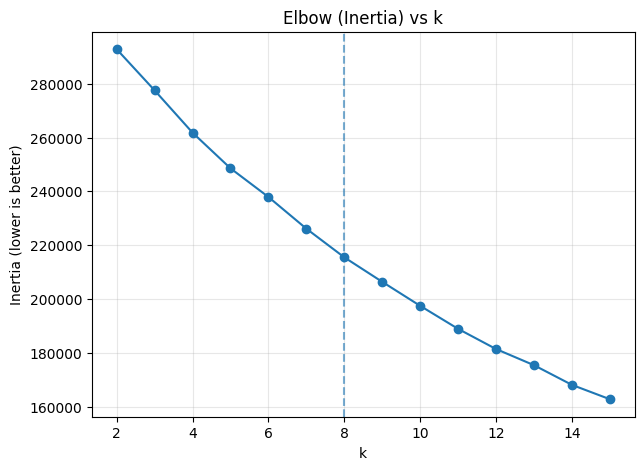

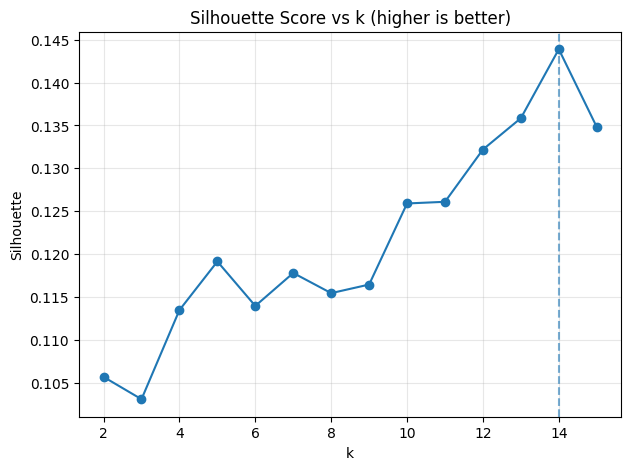

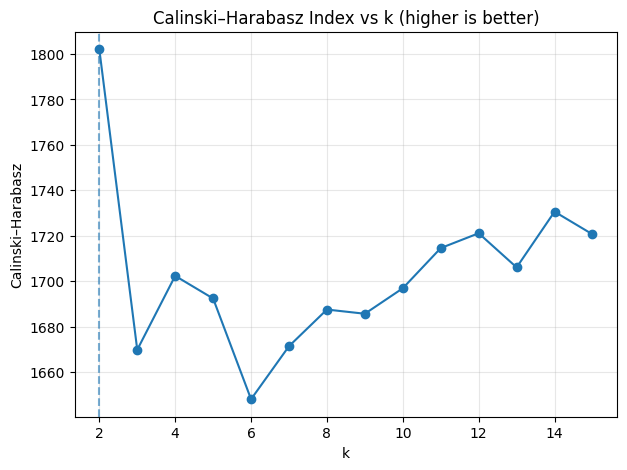

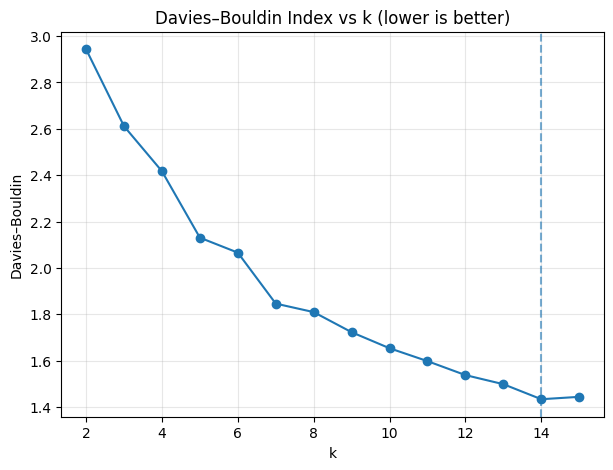

Per-metric winners: {'elbow_inertia': 8, 'silhouette': 14, 'calinski_harabasz': 2, 'davies_bouldin': 14}
Suggested k (ensemble): 14

Fitting final KMeans with k = 14

Analyzing clusters using features: ['pca_component_1', 'pca_component_2', 'pca_component_3', 'pca_component_4', 'pca_component_5', 'pca_component_6', 'pca_component_7', 'pca_component_8', 'pca_component_9', 'pca_component_10', 'pca_component_11', 'pca_component_12']

Cluster Statistics:
shape: (14, 50)
┌─────────┬───────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ cluster ┆ count ┆ pca_compon ┆ pca_compon ┆ … ┆ pca_compon ┆ pca_compon ┆ pca_compon ┆ pca_compo │
│ ---     ┆ ---   ┆ ent_1_mean ┆ ent_2_mean ┆   ┆ ent_9_max  ┆ ent_10_max ┆ ent_11_max ┆ nent_12_m │
│ i32     ┆ u32   ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ax        │
│         ┆       ┆ f64        ┆ f64        ┆   ┆ f64        ┆ f64        ┆ f64        ┆ ---       │
│         ┆       ┆     

cluster,count,pca_component_1_mean,pca_component_2_mean,pca_component_3_mean,pca_component_4_mean,pca_component_5_mean,pca_component_6_mean,pca_component_7_mean,pca_component_8_mean,pca_component_9_mean,pca_component_10_mean,pca_component_11_mean,pca_component_12_mean,pca_component_1_std,pca_component_2_std,pca_component_3_std,pca_component_4_std,pca_component_5_std,pca_component_6_std,pca_component_7_std,pca_component_8_std,pca_component_9_std,pca_component_10_std,pca_component_11_std,pca_component_12_std,pca_component_1_min,pca_component_2_min,pca_component_3_min,pca_component_4_min,pca_component_5_min,pca_component_6_min,pca_component_7_min,pca_component_8_min,pca_component_9_min,pca_component_10_min,pca_component_11_min,pca_component_12_min,pca_component_1_max,pca_component_2_max,pca_component_3_max,pca_component_4_max,pca_component_5_max,pca_component_6_max,pca_component_7_max,pca_component_8_max,pca_component_9_max,pca_component_10_max,pca_component_11_max,pca_component_12_max
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,2497,-0.428559,-1.272077,-1.19772,0.081158,-0.108976,0.11514,1.2722,1.200181,0.145475,0.304112,-0.062505,-0.085424,1.34225,0.557152,0.56365,0.611397,0.672829,0.895954,0.875759,0.744404,0.294145,0.631328,0.283462,0.493306,-8.062269,-2.820288,-3.268038,-2.293397,-3.196818,-1.976961,-1.447444,-0.63353,-1.071678,-1.792794,-1.078623,-3.1699,5.911509,2.505375,1.39856,1.996736,2.142281,2.084088,4.729935,4.762593,2.396863,3.877316,0.768325,1.915158
1,1500,0.44223,1.272541,1.689314,-1.64472,-0.679811,-0.596235,-0.373877,1.004802,-0.009156,0.590987,-0.35179,-0.005448,1.34941,0.982751,1.320904,1.044636,0.966677,0.935577,0.668334,0.834809,0.589634,0.601149,0.642509,0.472398,-8.966905,-0.611788,-0.763805,-4.852525,-4.910239,-2.878819,-3.726754,-0.719896,-1.975354,-1.435503,-6.715089,-3.833135,7.433333,8.502225,10.876719,3.446668,2.550112,2.48697,2.389975,4.625721,3.861481,4.236427,0.928424,2.72333
2,520,0.091416,3.425916,-0.075394,-0.11569,1.463626,0.3334,0.929837,-0.607195,3.763131,-0.097185,0.173842,0.003407,0.753207,2.709366,1.141525,1.088684,0.90802,0.657122,0.774289,0.658686,2.301484,0.391344,0.476213,0.224974,-3.693567,-0.023679,-4.05555,-3.66259,-1.545535,-1.873591,-0.550298,-3.489541,1.265786,-1.760956,-2.475917,-1.373451,2.815553,20.026581,3.994296,5.59117,7.093137,2.840975,6.451176,2.961533,21.906205,1.719425,1.443029,1.056737
3,1194,1.925066,-0.324402,0.33623,0.201025,-1.617615,0.751874,0.693553,-0.867211,-0.034038,-0.146536,-0.248451,-0.698043,1.30464,0.789287,1.076651,1.020735,1.169155,0.896806,0.851753,0.700205,0.363485,0.913244,0.554071,0.584604,-2.079384,-1.723447,-1.810908,-3.295763,-7.764845,-1.506327,-1.456023,-4.164435,-1.5743,-2.905624,-2.662922,-3.390591,8.468889,3.706073,6.84798,3.993825,1.234696,3.298092,4.41438,1.252928,1.560582,3.222023,1.376509,1.091731
4,201,1.034733,-0.136361,1.744524,4.695393,-3.69886,-0.46018,-2.469379,0.703267,1.485515,1.279665,2.004016,-0.290807,3.034006,1.081112,2.221061,2.756643,2.293926,1.429149,1.67435,1.270972,1.231503,1.646308,1.9761,1.066788,-12.24755,-2.811225,-1.810285,0.992388,-12.761003,-4.370469,-12.097918,-2.076676,-0.651209,-4.307932,-5.257208,-4.230193,16.594432,2.925897,12.593213,18.180341,-0.2324,2.393244,-0.078148,4.505904,7.765526,7.824132,11.979508,4.922792
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9,4237,-0.405837,-0.590334,0.318974,0.595255,0.635518,0.430534,-0.34286,-0.272168,-0.0458,0.025869,-0.601292,-0.054409,1.275076,0.582669,1.237701,0.646107,0.620774,0.508062,0.575592,0.573004,0.409323,0.628363,0.508215,0.486186,-13.078993,-1.554905,-2.208925,-1.356541,-1.723184,-2.055006,-3.29415,-1.853689,-1.637025,-2.046631,-8.495896,-4.951591,4.024444,3.427351,16.211794,8.178136,3.930931,3.720736,2.560968,4.074204,3.200555,3.534394,0.725499,

In [14]:
# Option A: raw features
# feature_set = ['implied_volatility', 'delta', 'gamma']

# Option B: PCA components (if you've run apply_pca_preprocessing and have pca_cols)
feature_set = pca_cols

#k_range = auto_k_range(spy_df, feature_set) #uncomment for raw
k_range = auto_k_range(result, feature_set) # uncomment for reduced

clustered_auto_df, kscan = choose_k_and_cluster(
    df=result,                  # or `result` if you're clustering on the PCA-augmented DF
    feature_cols=feature_set,
    k_range=k_range,
    standardize=True,
    random_state=42,
    n_init=20,
)

# Inspect the chosen k and re-run your cluster analysis summary on the new labels:
cluster_stats_auto = analyze_clusters(clustered_auto_df, feature_cols=feature_set, cluster_col="cluster")
cluster_stats_auto



Sampling ≈5.0% of rows (columns=16)
Loaded 65 rows out of 1,304


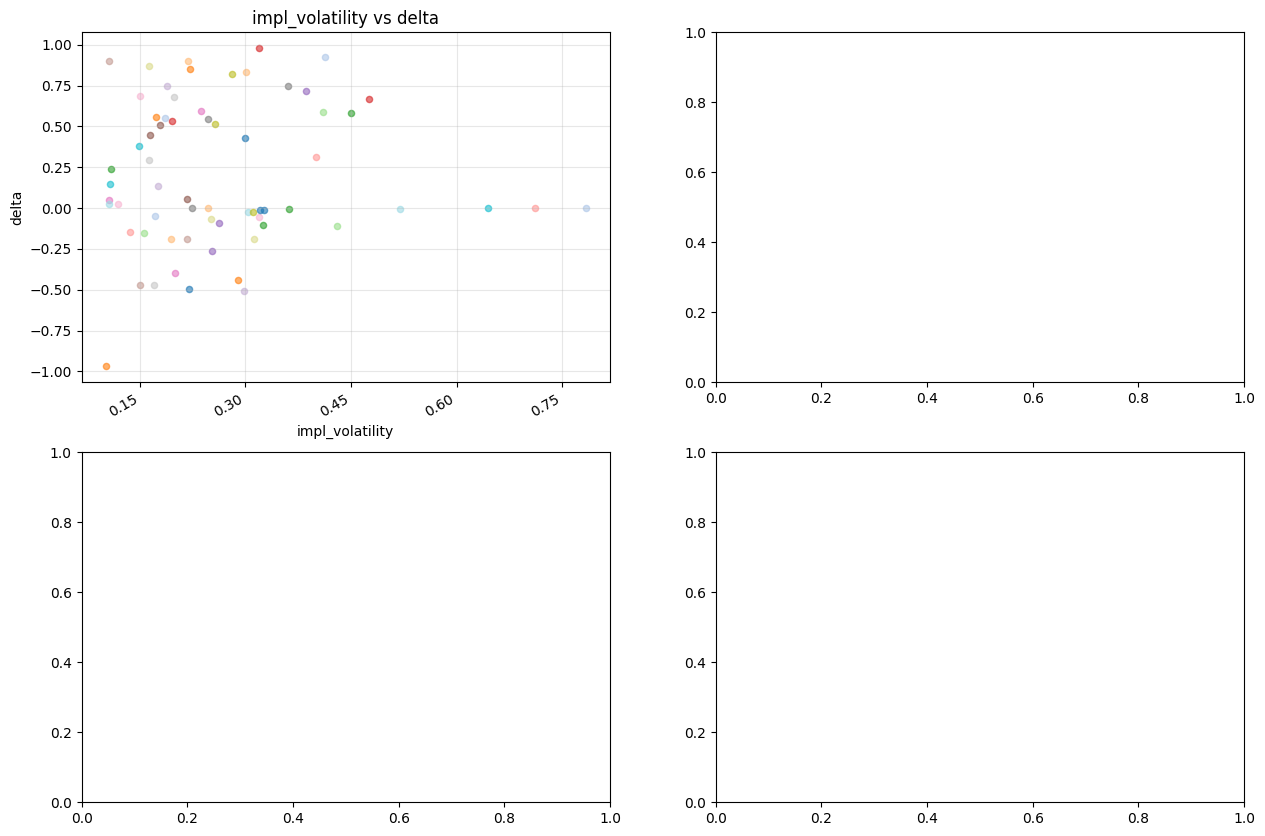

In [16]:
#save clustered_auto_df to parquet
# clustered_auto_df.write_parquet("../drive/MyDrive/clustered_auto_df.parquet")
clustered_auto_df.write_parquet("clustered_auto_df.parquet")

# !ls
## load clustered
# clustered_auto_df = lazy_sample_parquet("./drive/MyDrive/Copy of clustered_auto_df.parquet", fraction=0.05, columns=numeric_features)
clustered_auto_df = lazy_sample_parquet("clustered_auto_df.parquet", fraction=0.05, columns=numeric_features)

regime_dashboard_windows(df=clustered_auto_df.to_pandas(), label_col='theta')